In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [41]:
import pandas as pd
file_path = r"C:\Users\sudar\Documents\Collage\Placement prep\Machine learing and computer vison\Home Assignment\Home Assingment 2\data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [42]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [43]:
print("Number of Samples:", df.shape[0])
print("Number of Features/Columns:", df.shape[1])

Number of Samples: 569
Number of Features/Columns: 32


In [44]:
df.dtypes

id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [45]:
print("Columns:")
print(df.columns.tolist())

Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [46]:
print("\nTarget Column:")
print(df["diagnosis"].value_counts())


Target Column:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [47]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

print("\nTotal Missing Values:",
      df.isnull().sum().sum())

Series([], dtype: int64)

Total Missing Values: 0


In [48]:
print(df["diagnosis"].value_counts())

print("\nClass Distribution (%):")
print(
    df["diagnosis"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

diagnosis
B    357
M    212
Name: count, dtype: int64

Class Distribution (%):
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


In [49]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [50]:
df = df.drop("id", axis=1)

In [51]:
print(df.columns.tolist())

['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [52]:
df = df.drop(
    columns=["id", "Unnamed: 32"],
    errors="ignore"
)

print("Dataset Shape After Cleaning:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())

Dataset Shape After Cleaning: (569, 31)
Total Missing Values: 0


In [53]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


X → 30 input features (569, 30)
y → diagnosis (B / M) (569,)

In [54]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original Classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y_encoded))

Original Classes: ['B' 'M']
Encoded classes: [0 1]


In [56]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original Classes:", label_encoder.classes_)
print("Encoded Classes:", np.unique(y_encoded))
print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

Original Classes: ['B' 'M']
Encoded Classes: [0 1]
{'B': np.int64(0), 'M': np.int64(1)}


### Target Encoding

The diagnosis labels were encoded numerically: Benign (B) = 0 and Malignant (M) = 1.

In [57]:
print("Encoded Class Distribution:")
print(pd.Series(y_encoded).value_counts().sort_index())

Encoded Class Distribution:
0    357
1    212
Name: count, dtype: int64


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (455, 30)
Testing Set: (114, 30)


In [59]:
stratify=y_encoded

In [60]:
print("Training Class Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Class Distribution:")
print(pd.Series(y_test).value_counts())

Training Class Distribution:
0    285
1    170
Name: count, dtype: int64

Testing Class Distribution:
0    72
1    42
Name: count, dtype: int64


In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Scaled Training Shape: (455, 30)
Scaled Testing Shape: (114, 30)


### Feature Scaling

StandardScaler was fitted on the training data and applied to both training and testing features to place all numerical features on a comparable scale while avoiding data leakage.

In [63]:
print("===== FINAL PREPROCESSING CHECK =====")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

print("\nTraining Classes:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting Classes:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nMissing Values in Original Cleaned Data:",
      df.isnull().sum().sum())

===== FINAL PREPROCESSING CHECK =====
X_train: (455, 30)
X_test : (114, 30)
X_train_scaled: (455, 30)
X_test_scaled : (114, 30)

Training Classes:
0    285
1    170
Name: count, dtype: int64

Testing Classes:
0    72
1    42
Name: count, dtype: int64

Missing Values in Original Cleaned Data: 0


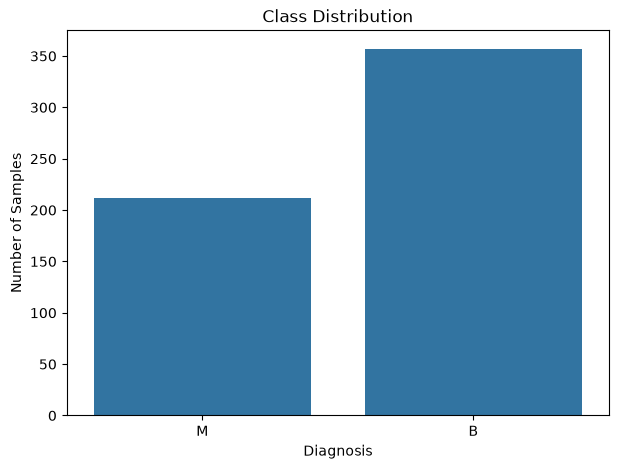

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

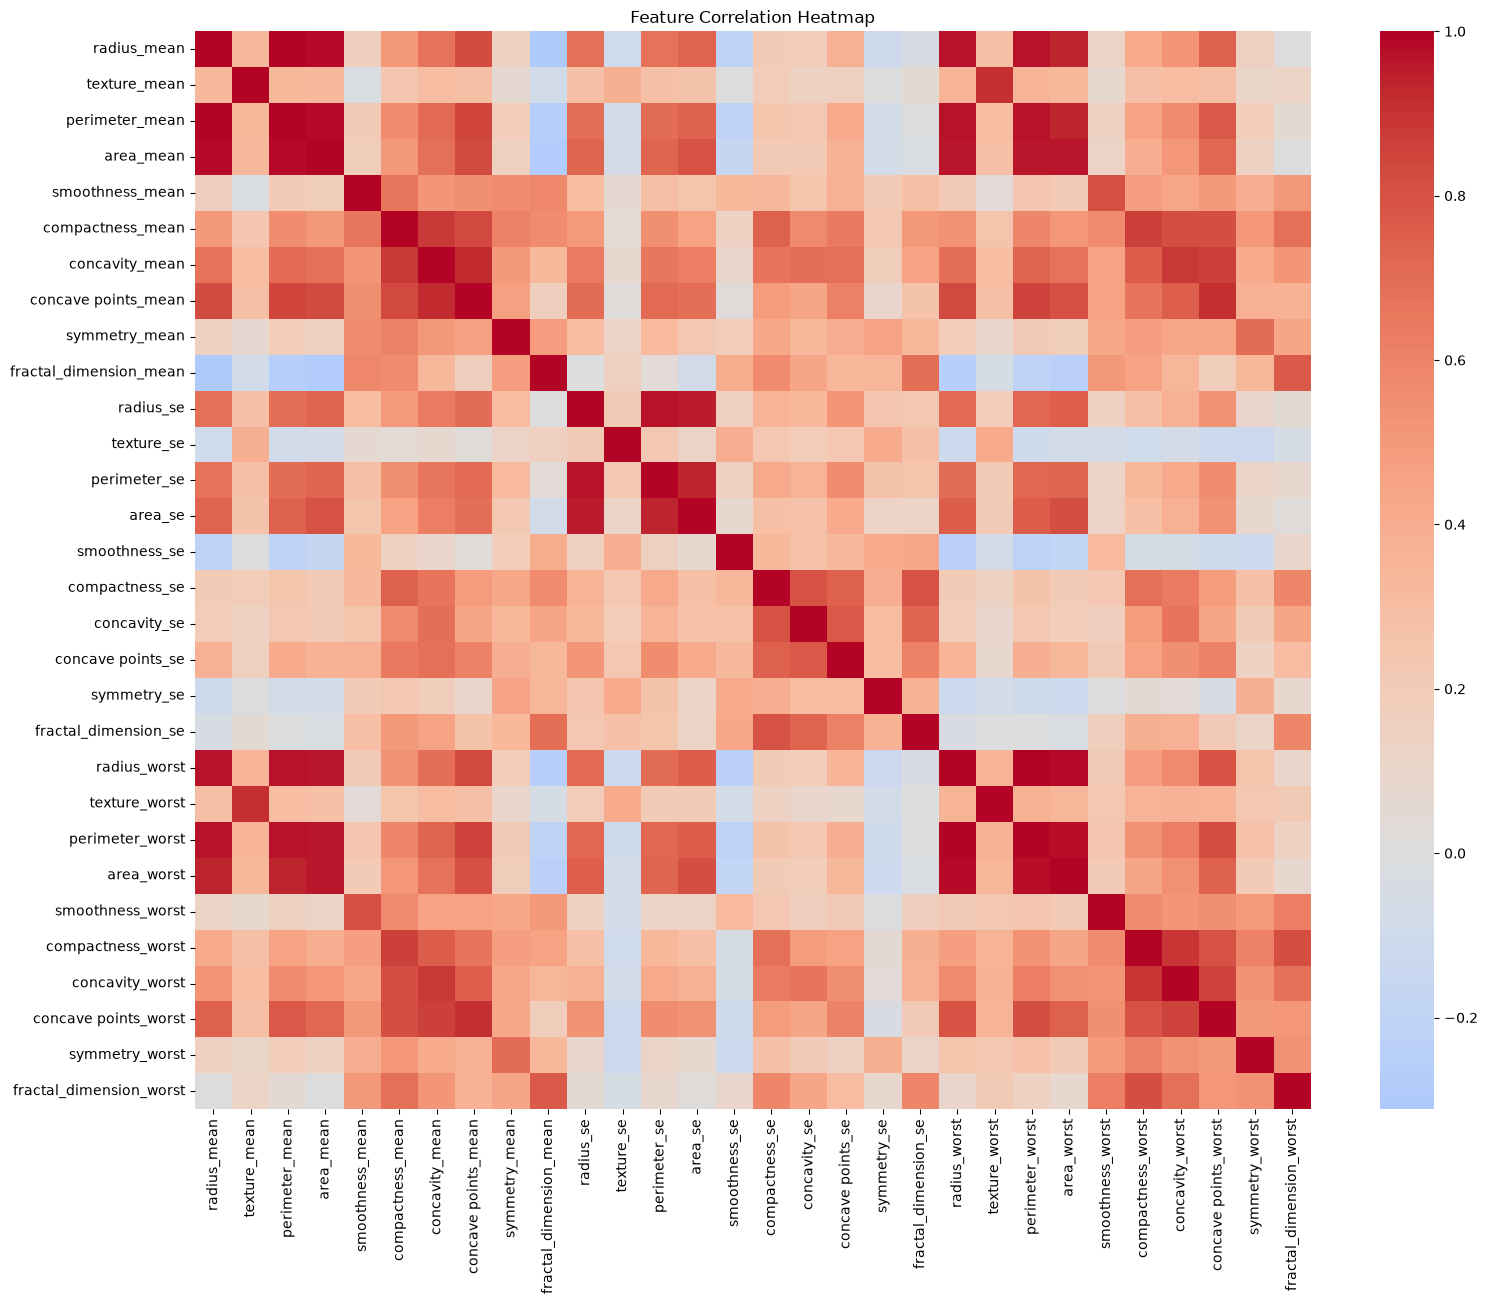

In [65]:
plt.figure(figsize=(18, 14))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

### Correlation Heatmap

Several features show strong positive correlations, especially measurements related to radius, perimeter, and area, indicating possible redundancy among features.

In [66]:
correlation_with_target = df.drop(columns=["diagnosis"]).corrwith(
    pd.Series(y_encoded, index=df.index)
)

top_features = correlation_with_target.abs().sort_values(
    ascending=False
).head(10)

print("Top 10 Features Related to Diagnosis:")
print(top_features)

Top 10 Features Related to Diagnosis:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
dtype: float64


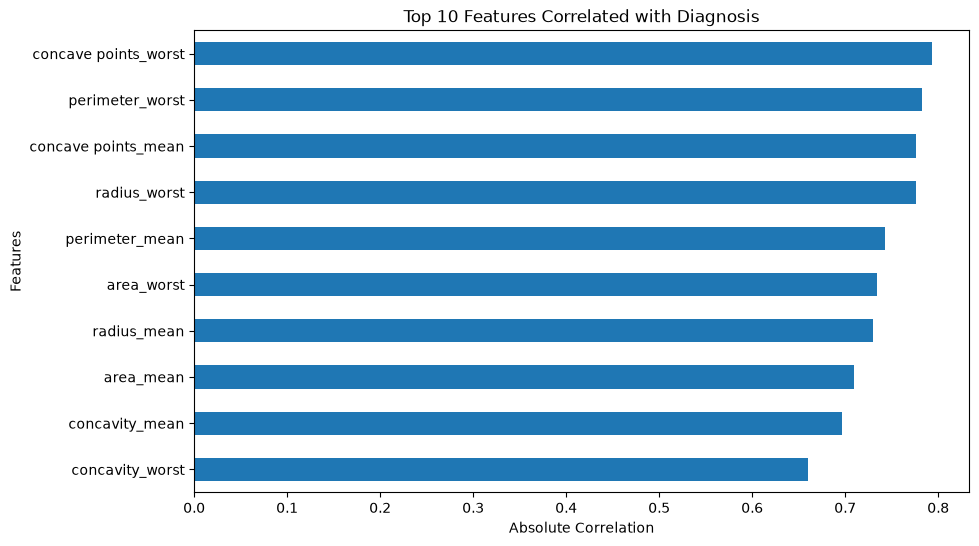

In [67]:
plt.figure(figsize=(10, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Features Correlated with Diagnosis")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")

plt.show()

### Feature-Target Relationship

The strongest correlated features are useful candidates for visual analysis because they show greater association with the benign/malignant target.

In [68]:
selected_features = top_features.index[:4].tolist()

print("Selected Features:")
print(selected_features)

Selected Features:
['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst']


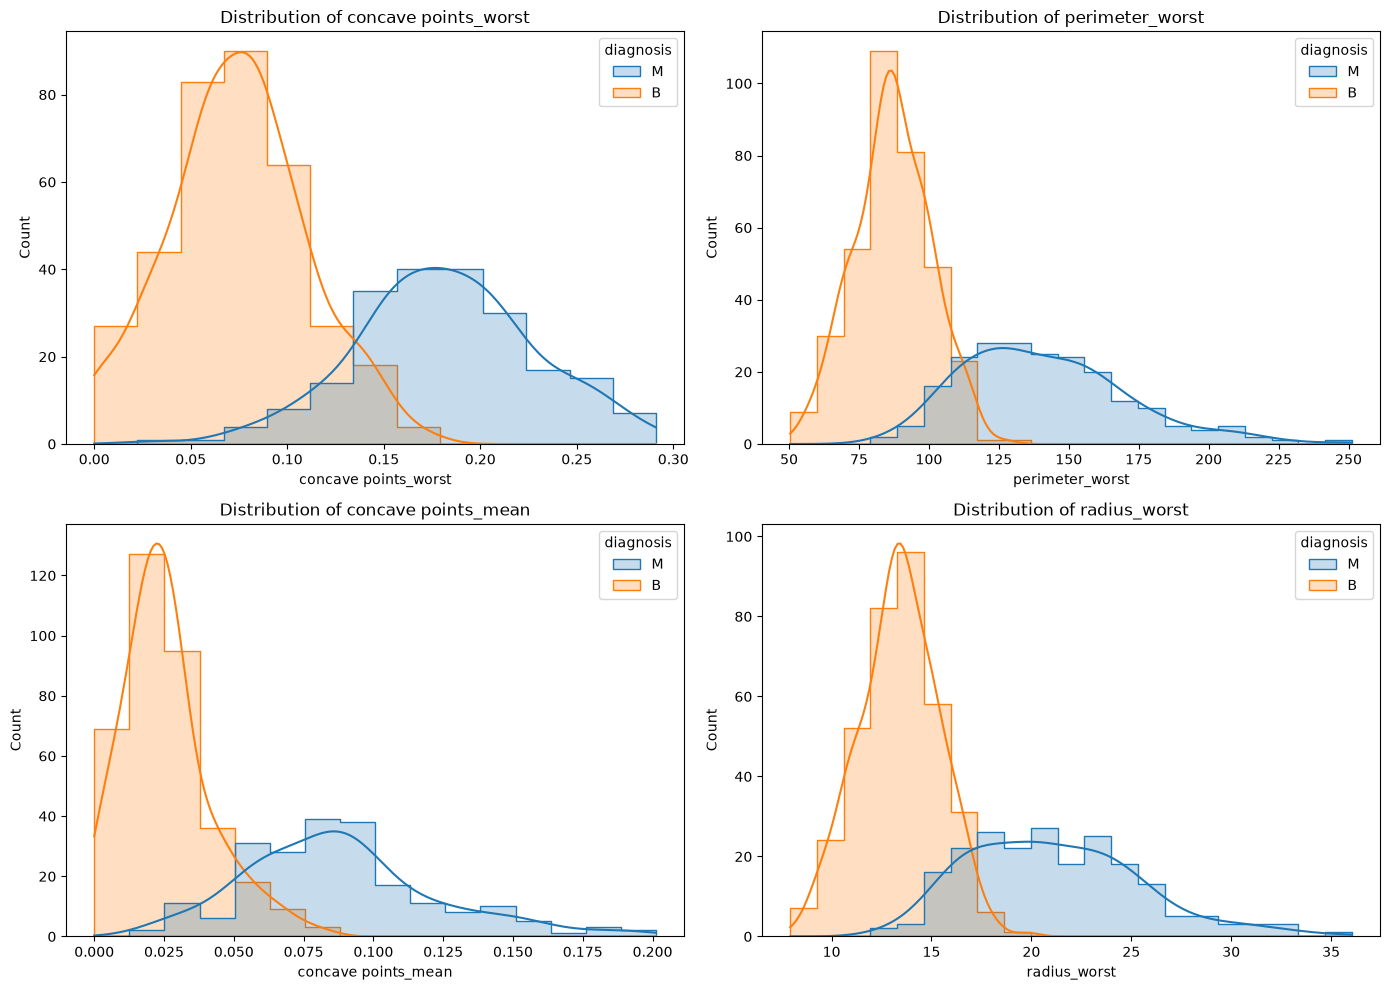

In [69]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

for ax, feature in zip(axes.flatten(), selected_features):

    sns.histplot(
        data=df,
        x=feature,
        hue="diagnosis",
        kde=True,
        element="step",
        ax=ax
    )

    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

### Feature Distributions

The distributions of several important features differ between benign and malignant samples, suggesting that these features contain useful classification information.

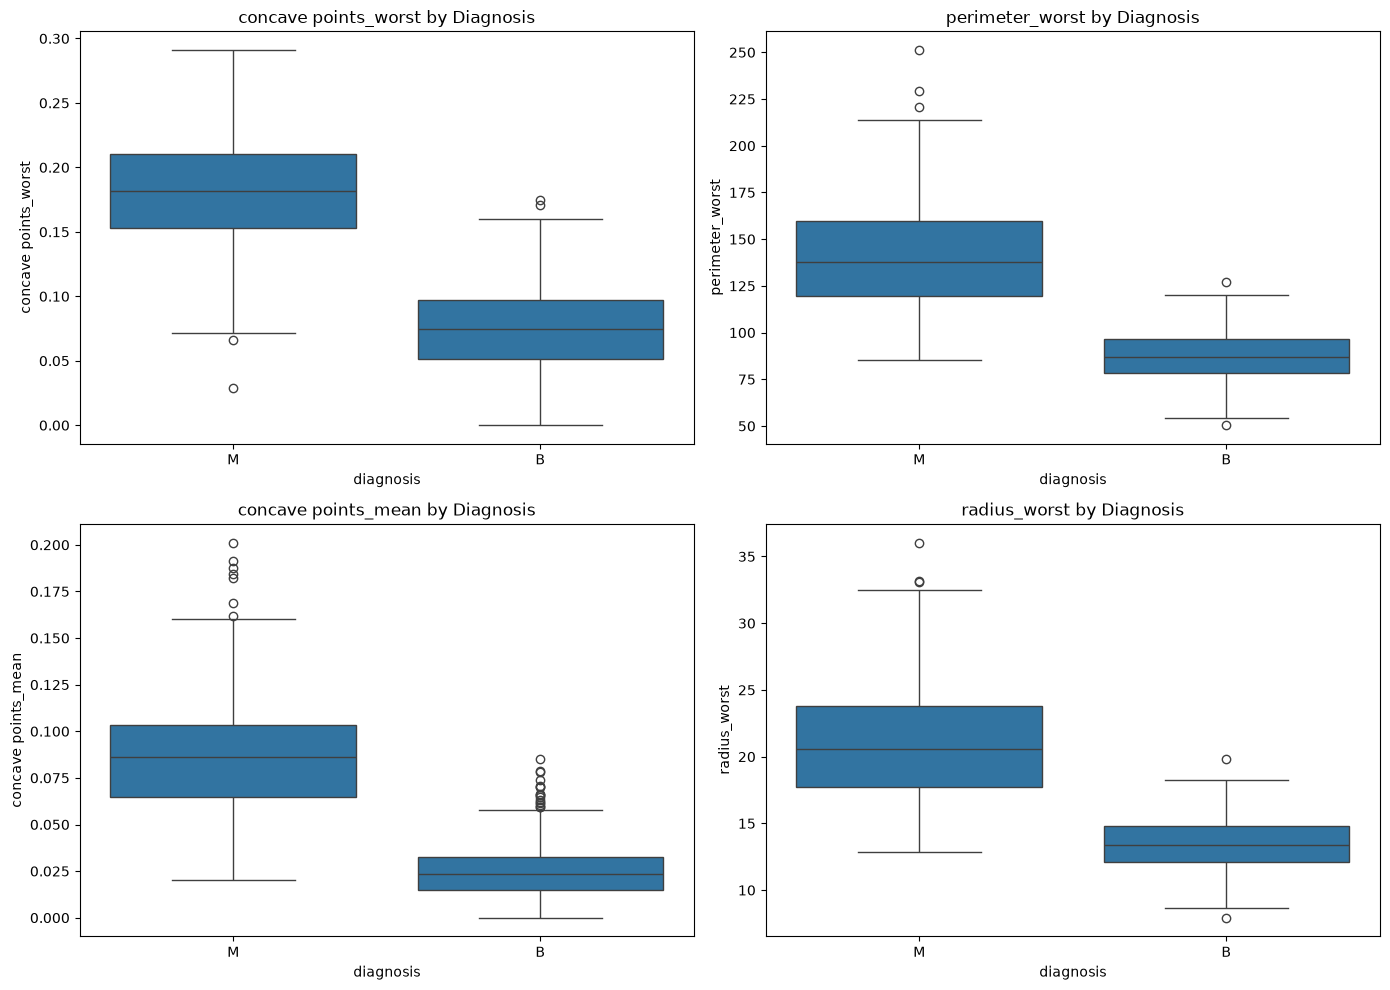

In [70]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

for ax, feature in zip(axes.flatten(), selected_features):

    sns.boxplot(
        data=df,
        x="diagnosis",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} by Diagnosis")

plt.tight_layout()
plt.show()

### Boxplot Comparison

The boxplots show differences in the central tendency and spread of important features between benign and malignant samples, supporting their predictive usefulness.

X-axis Feature: concave points_worst
Y-axis Feature: perimeter_worst


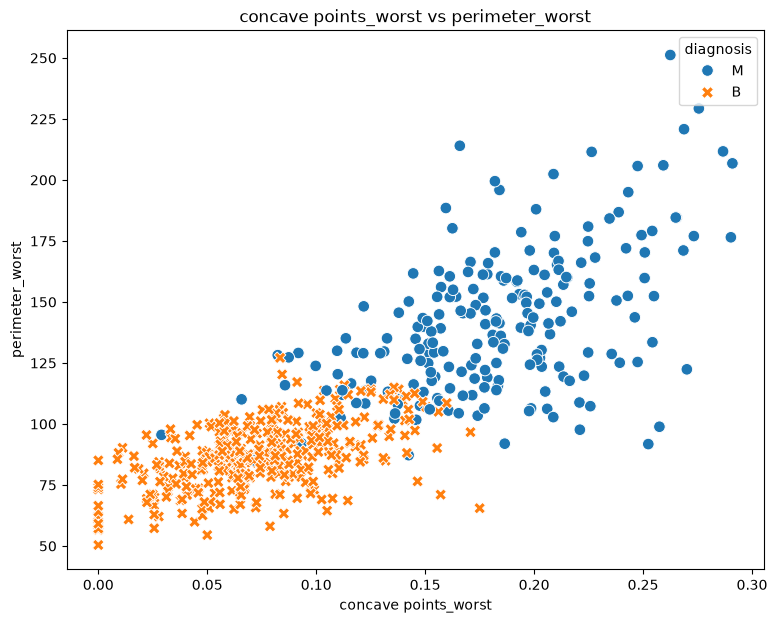

In [71]:
feature_x = top_features.index[0]
feature_y = top_features.index[1]

print("X-axis Feature:", feature_x)
print("Y-axis Feature:", feature_y)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df,
    x=feature_x,
    y=feature_y,
    hue="diagnosis",
    style="diagnosis",
    s=70
)

plt.title(f"{feature_x} vs {feature_y}")
plt.xlabel(feature_x)
plt.ylabel(feature_y)

plt.show()

### Feature Scatter Plot

The scatter plot shows partial separation between benign and malignant samples, although some overlap exists; using multiple features should improve classification.

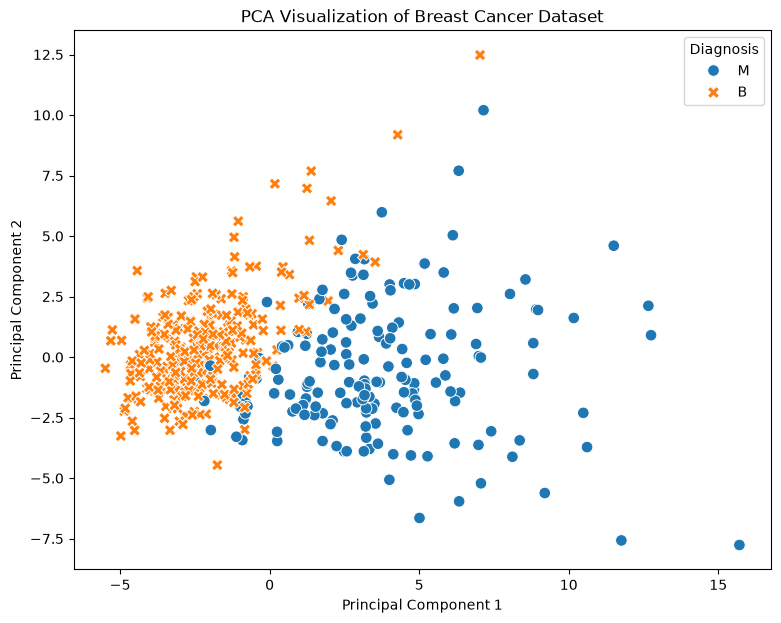

In [72]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Diagnosis"] = y_train

pca_df["Diagnosis"] = pca_df["Diagnosis"].map({
    0: "B",
    1: "M"
})

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    style="Diagnosis",
    s=70
)

plt.title("PCA Visualization of Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [73]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total Variance Explained:",
    pca.explained_variance_ratio_.sum()
)

Explained Variance Ratio:
[0.44593522 0.18545255]
Total Variance Explained: 0.631387776559559


### PCA Explained Variance

The first two principal components capture a portion of the total dataset variance, providing a compact 2D representation of the original feature space.

In [74]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

### Part C: Logistic Regression

Logistic Regression was selected as the first classification algorithm, and multiple regularization strengths will be evaluated using C = 0.01, 0.1, 1, and 10.

In [75]:
C_values = [0.01, 0.1, 1, 10]

logistic_models = {}
logistic_results = {}

for C in C_values:

    model = LogisticRegression(
        C=C,
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    logistic_models[C] = model

    logistic_results[C] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

print("All Logistic Regression models trained successfully.")

All Logistic Regression models trained successfully.


In [77]:
logistic_results_df = pd.DataFrame(
    logistic_results
).T

logistic_results_df.index.name = "C"

logistic_results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
C,,,,,
0.01,0.947368,1.00000,0.857143,0.923077,0.997685
0.10,0.982456,1.00000,0.952381,0.975610,0.997685
1.00,0.964912,0.97500,0.928571,0.951220,0.996032
10.00,0.973684,0.97561,0.952381,0.963855,0.986442


In [78]:
print("Best C by Accuracy:",
      logistic_results_df["Accuracy"].idxmax())

print("Best C by Precision:",
      logistic_results_df["Precision"].idxmax())

print("Best C by Recall:",
      logistic_results_df["Recall"].idxmax())

print("Best C by F1-score:",
      logistic_results_df["F1-score"].idxmax())

print("Best C by ROC-AUC:",
      logistic_results_df["ROC-AUC"].idxmax())

Best C by Accuracy: 0.1
Best C by Precision: 0.01
Best C by Recall: 0.1
Best C by F1-score: 0.1
Best C by ROC-AUC: 0.1


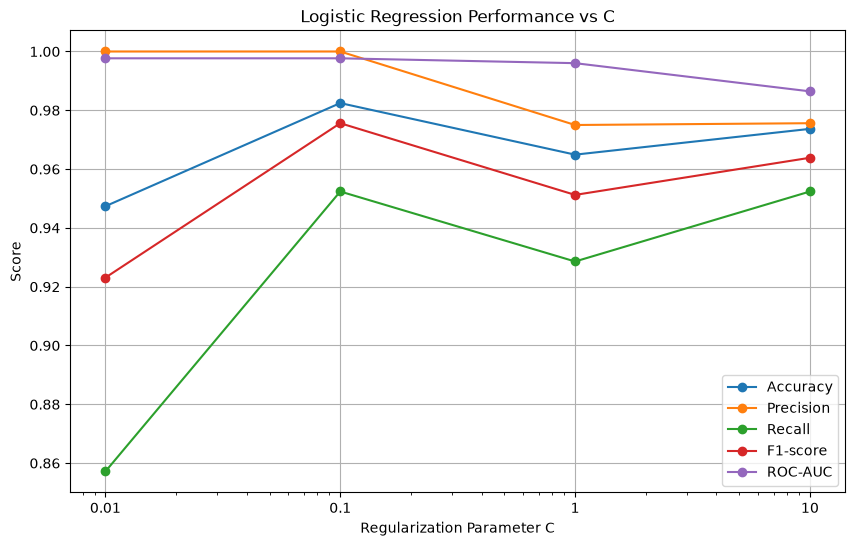

In [79]:
plt.figure(figsize=(10, 6))

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]:
    
    plt.plot(
        C_values,
        logistic_results_df[metric],
        marker="o",
        label=metric
    )

plt.xscale("log")

plt.xlabel("Regularization Parameter C")
plt.ylabel("Score")
plt.title("Logistic Regression Performance vs C")

plt.xticks(C_values, [str(c) for c in C_values])
plt.legend()
plt.grid(True)

plt.show()

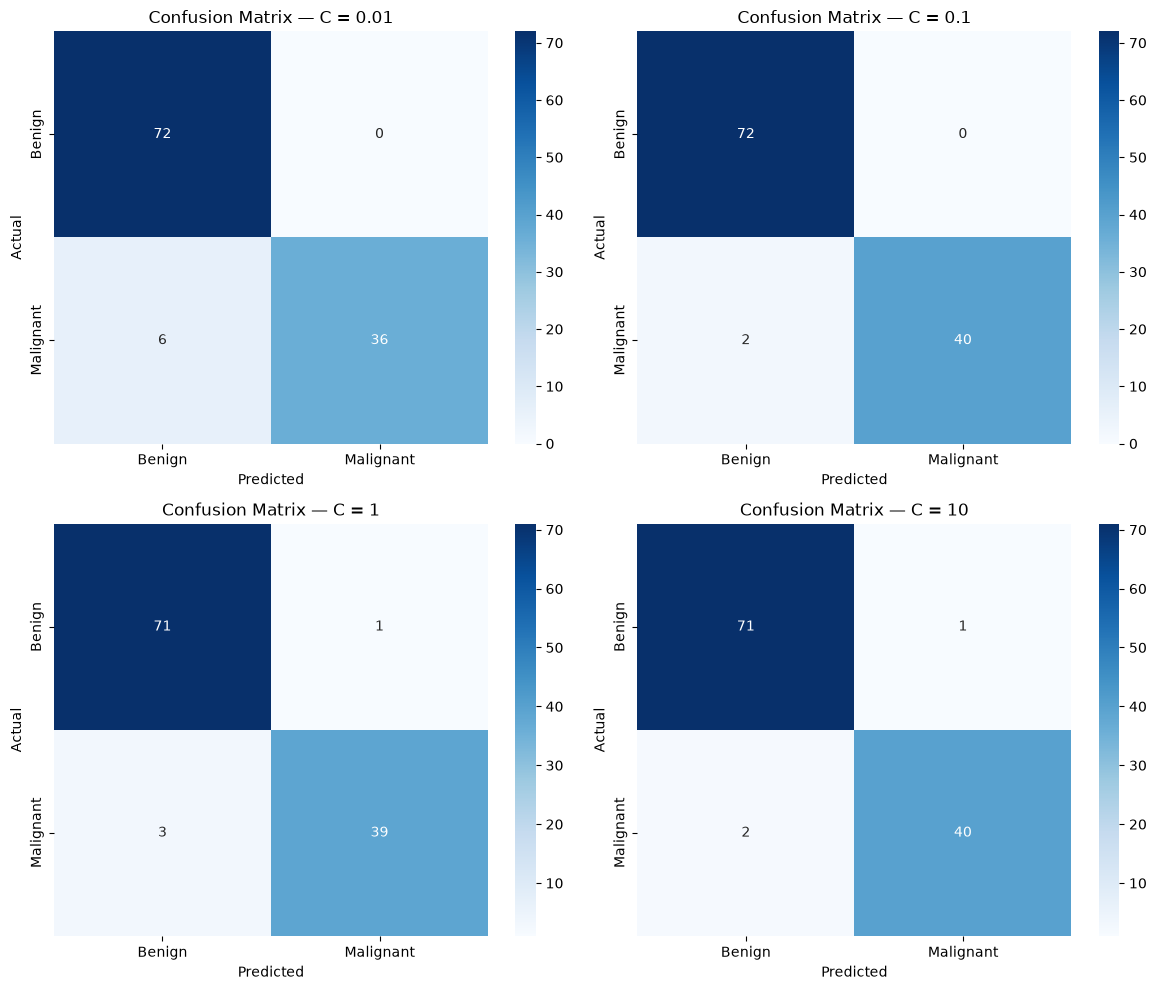

In [80]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10)
)

for ax, C in zip(axes.flatten(), C_values):

    model = logistic_models[C]

    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )

    ax.set_title(f"Confusion Matrix — C = {C}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [81]:
for C in C_values:

    y_pred = logistic_models[C].predict(X_test_scaled)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    print(f"\nC = {C}")
    print("True Negative (TN):", tn)
    print("False Positive (FP):", fp)
    print("False Negative (FN):", fn)
    print("True Positive (TP):", tp)


C = 0.01
True Negative (TN): 72
False Positive (FP): 0
False Negative (FN): 6
True Positive (TP): 36

C = 0.1
True Negative (TN): 72
False Positive (FP): 0
False Negative (FN): 2
True Positive (TP): 40

C = 1
True Negative (TN): 71
False Positive (FP): 1
False Negative (FN): 3
True Positive (TP): 39

C = 10
True Negative (TN): 71
False Positive (FP): 1
False Negative (FN): 2
True Positive (TP): 40


In [82]:
for C in C_values:

    y_pred = logistic_models[C].predict(X_test_scaled)

    print("=" * 60)
    print(f"Classification Report — C = {C}")
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Benign", "Malignant"]
        )
    )

Classification Report — C = 0.01
              precision    recall  f1-score   support

      Benign       0.92      1.00      0.96        72
   Malignant       1.00      0.86      0.92        42

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

Classification Report — C = 0.1
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Classification Report — C = 1
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96

### Misclassification Analysis

C = 0.1 produced only 2 false negatives and 0 false positives, making it the preferred Logistic Regression configuration.

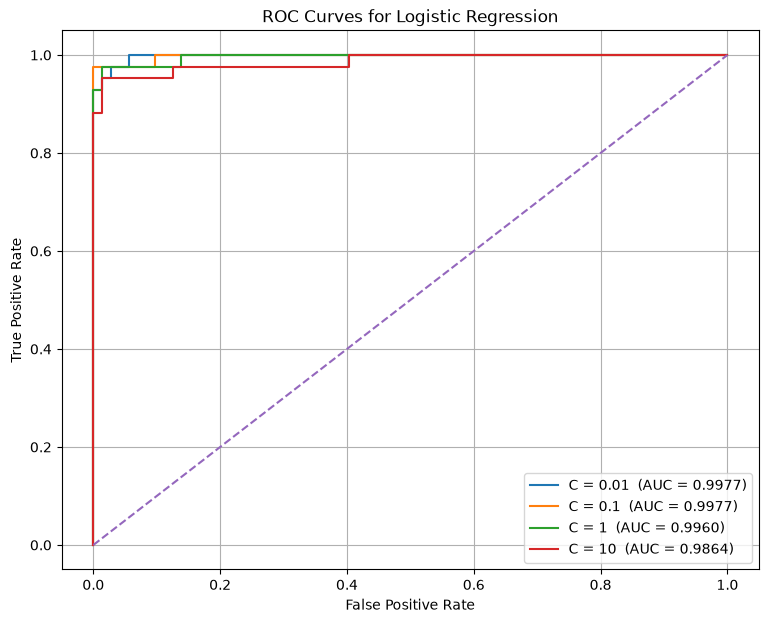

In [83]:
plt.figure(figsize=(9, 7))

for C in C_values:

    model = logistic_models[C]

    y_prob = model.predict_proba(
        X_test_scaled
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"C = {C}  (AUC = {auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression")

plt.legend()
plt.grid(True)

plt.show()

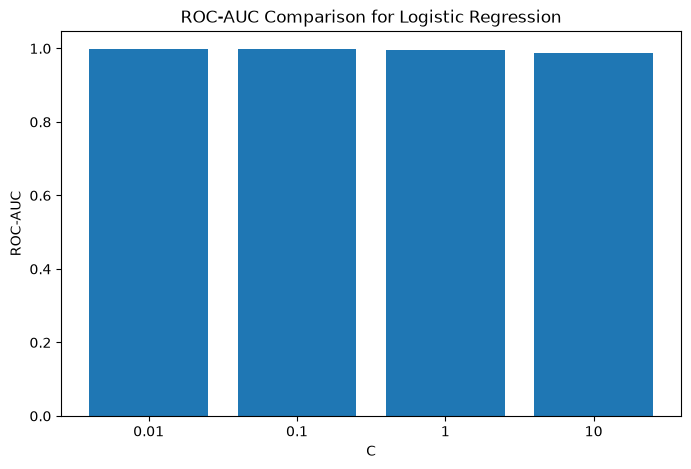

In [84]:
plt.figure(figsize=(8, 5))

plt.bar(
    [str(c) for c in C_values],
    logistic_results_df["ROC-AUC"]
)

plt.xlabel("C")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison for Logistic Regression")

plt.show()

In [85]:
final_logistic_table = logistic_results_df.copy()

final_logistic_table["FP"] = 0
final_logistic_table["FN"] = 0

for C in C_values:

    y_pred = logistic_models[C].predict(
        X_test_scaled
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    final_logistic_table.loc[C, "FP"] = fp
    final_logistic_table.loc[C, "FN"] = fn

final_logistic_table

,Accuracy,Precision,Recall,F1-score,ROC-AUC,FP,FN
C,,,,,,,
0.01,0.947368,1.00000,0.857143,0.923077,0.997685,0,6
0.10,0.982456,1.00000,0.952381,0.975610,0.997685,0,2
1.00,0.964912,0.97500,0.928571,0.951220,0.996032,1,3
10.00,0.973684,0.97561,0.952381,0.963855,0.986442,1,2


### Logistic Regression Analysis

C = 0.1 achieved the best overall performance with 98.25% accuracy, 97.56% F1-score, 99.77% ROC-AUC, 0 false positives, and only 2 false negatives.

Part D: Gaussian Naive Bayes

In [86]:
from sklearn.naive_bayes import GaussianNB

### Part D: Gaussian Naive Bayes

Gaussian Naive Bayes is implemented as a probabilistic classifier that assumes the features are conditionally independent given the class.

In [87]:
gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [88]:
y_pred_gnb = gnb.predict(X_test_scaled)

y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [89]:
gnb_accuracy = accuracy_score(y_test, y_pred_gnb)
gnb_precision = precision_score(y_test, y_pred_gnb)
gnb_recall = recall_score(y_test, y_pred_gnb)
gnb_f1 = f1_score(y_test, y_pred_gnb)
gnb_roc_auc = roc_auc_score(y_test, y_prob_gnb)

print("Accuracy :", gnb_accuracy)
print("Precision:", gnb_precision)
print("Recall   :", gnb_recall)
print("F1-score :", gnb_f1)
print("ROC-AUC  :", gnb_roc_auc)

Accuracy : 0.9210526315789473
Precision: 0.9230769230769231
Recall   : 0.8571428571428571
F1-score : 0.8888888888888888
ROC-AUC  : 0.9890873015873015


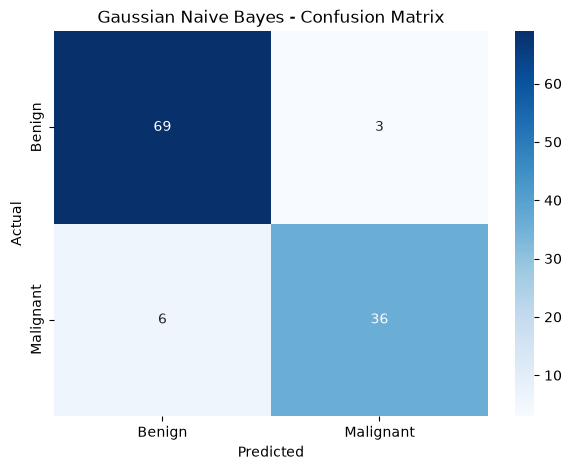

In [90]:
cm_gnb = confusion_matrix(
    y_test,
    y_pred_gnb
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_gnb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [91]:
tn, fp, fn, tp = cm_gnb.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

True Negative (TN): 69
False Positive (FP): 3
False Negative (FN): 6
True Positive (TP): 36


In [92]:
print(
    classification_report(
        y_test,
        y_pred_gnb,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.92      0.96      0.94        72
   Malignant       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



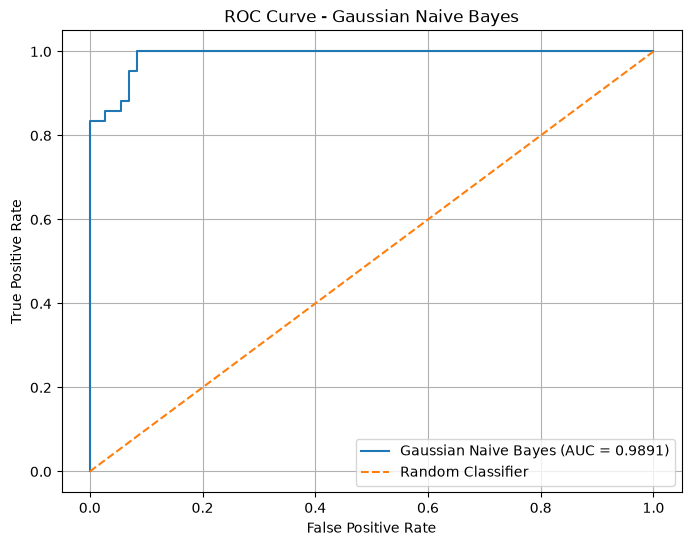

In [93]:
fpr_gnb, tpr_gnb, thresholds_gnb = roc_curve(
    y_test,
    y_prob_gnb
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_gnb,
    tpr_gnb,
    label=f"Gaussian Naive Bayes (AUC = {gnb_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gaussian Naive Bayes")

plt.legend()
plt.grid(True)

plt.show()

### ROC Curve

The ROC curve shows the trade-off between true-positive and false-positive rates, while ROC-AUC measures the model's ability to distinguish benign and malignant samples.

In [94]:
gnb_results = pd.DataFrame({
    "Model": ["Gaussian Naive Bayes"],
    "Accuracy": [gnb_accuracy],
    "Precision": [gnb_precision],
    "Recall": [gnb_recall],
    "F1-score": [gnb_f1],
    "ROC-AUC": [gnb_roc_auc],
    "FP": [fp],
    "FN": [fn]
})

gnb_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,FP,FN
0,Gaussian Naive Bayes,0.921053,0.923077,0.857143,0.888889,0.989087,3,6


In [95]:
logistic_best = logistic_results_df.loc[0.1]

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (C=0.1)",
        "Gaussian Naive Bayes"
    ],
    "Accuracy": [
        logistic_best["Accuracy"],
        gnb_accuracy
    ],
    "Precision": [
        logistic_best["Precision"],
        gnb_precision
    ],
    "Recall": [
        logistic_best["Recall"],
        gnb_recall
    ],
    "F1-score": [
        logistic_best["F1-score"],
        gnb_f1
    ],
    "ROC-AUC": [
        logistic_best["ROC-AUC"],
        gnb_roc_auc
    ],
    "FP": [
        final_logistic_table.loc[0.1, "FP"],
        fp
    ],
    "FN": [
        final_logistic_table.loc[0.1, "FN"],
        fn
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,FP,FN
0,Logistic Regression (C=0.1),0.982456,1.000000,0.952381,0.975610,0.997685,0,2
1,Gaussian Naive Bayes,0.921053,0.923077,0.857143,0.888889,0.989087,3,6


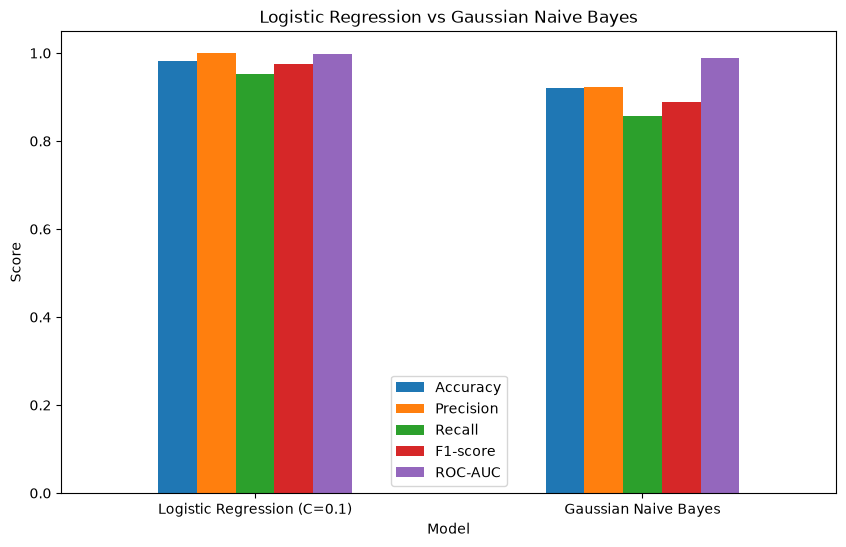

In [96]:
comparison_plot = comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs Gaussian Naive Bayes")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()

### Model Comparison

Logistic Regression and Gaussian Naive Bayes are compared using accuracy, precision, recall, F1-score, and ROC-AUC to identify their relative classification performance.

### Gaussian Naive Bayes Results

Gaussian Naive Bayes achieved 92.11% accuracy and 98.91% ROC-AUC, but produced 6 false negatives. Logistic Regression (C=0.1) performed better across the main classification metrics.

### Part D (iii) — Gaussian Naive Bayes Analysis

1. **Overall Performance:** Gaussian Naive Bayes achieved 92.11% accuracy and 98.91% ROC-AUC, showing good classification performance.

2. **Highest Precision:** Both Benign and Malignant classes have the same precision of 0.92.

3. **Highest Recall:** The Benign class has the higher recall (0.96), compared with 0.86 for Malignant.

4. **F1-score:** The F1-score is 0.94 for Benign and 0.89 for Malignant, indicating a better balance for the Benign class.

5. **Confusion Matrix:** The model produced 3 false positives and 6 false negatives. Accuracy alone does not show the type or cost of these errors.

6. **ROC-AUC:** The ROC-AUC of 0.9891 indicates excellent ability to distinguish between Benign and Malignant samples.

7. **Independence Assumption:** The Naive Bayes independence assumption is not fully reasonable because many features in this dataset are strongly correlated, as observed in the correlation heatmap.

8. **Advantages and Limitations:** Naive Bayes is simple, fast, and computationally efficient. However, its feature-independence assumption is a limitation for this dataset, where several features are highly correlated.

### Part D(iii) — Gaussian Naive Bayes Analysis

**1. How well does Gaussian Naive Bayes perform on the dataset?**  
Gaussian Naive Bayes achieved 92.11% accuracy and 98.91% ROC-AUC, showing good overall classification performance.

**2. Which class has the highest precision?**  
Both Benign and Malignant have the same precision of 0.92.

**3. Which class has the highest recall?**  
Benign has the higher recall of 0.96, while Malignant has a recall of 0.86.

**4. What does the F1-score tell you about the model?**  
The F1-score is 0.94 for Benign and 0.89 for Malignant, indicating better classification balance for the Benign class.

**5. What does the confusion matrix reveal that accuracy alone does not?**  
The confusion matrix shows the types of errors: 3 false positives and 6 false negatives. Accuracy alone does not show these individual errors.

**6. What does the ROC curve and ROC-AUC indicate?**  
The ROC-AUC of 0.9891 indicates excellent ability of the model to distinguish between Benign and Malignant samples.

**7. Is the Naive Bayes independence assumption reasonable for this dataset?**  
The assumption is not fully reasonable because several features are strongly correlated, as observed in the correlation heatmap.

**8. What are the major advantages and limitations of using Naive Bayes for this problem?**  
Naive Bayes is simple, fast, and computationally efficient. Its main limitation is the feature-independence assumption, which is not well satisfied because many features are correlated.

Part E — Decision Tree Classifier

In [97]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


In [98]:
param_grid_dt = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["entropy"]
}

print("Hyperparameter combinations will be tested.")

Hyperparameter combinations will be tested.


In [99]:
dt = DecisionTreeClassifier(
    random_state=42
)

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_dt.fit(X_train_scaled, y_train)

print("Grid Search completed.")

Grid Search completed.


Takes every parameter combination.
Performs 5-fold cross-validation.
Calculates validation accuracy.
Finds the best combination.

In [100]:
print("Best Hyperparameters:")
print(grid_search_dt.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search_dt.best_score_)

Best Hyperparameters:
{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best Cross-Validation Accuracy:
0.9494505494505494


In [101]:
best_dt_entropy = grid_search_dt.best_estimator_

y_pred_dt = best_dt_entropy.predict(X_test_scaled)
y_prob_dt = best_dt_entropy.predict_proba(X_test_scaled)[:, 1]

print("Best Decision Tree trained successfully.")

Best Decision Tree trained successfully.


In [102]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)
print("ROC-AUC  :", dt_roc_auc)

Accuracy : 0.9385964912280702
Precision: 1.0
Recall   : 0.8333333333333334
F1-score : 0.9090909090909091
ROC-AUC  : 0.9507275132275133


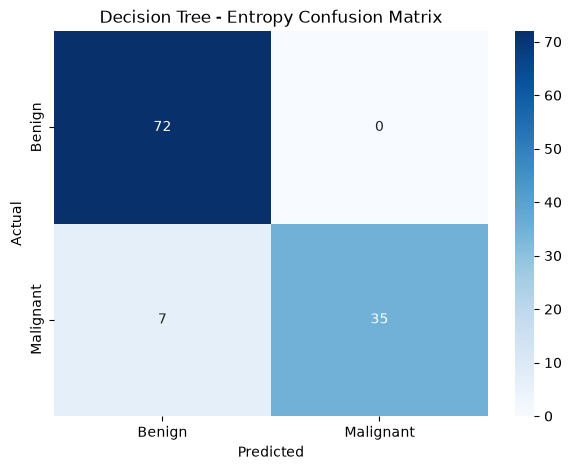

In [103]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Decision Tree - Entropy Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [104]:
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()

print("True Negative (TN):", tn_dt)
print("False Positive (FP):", fp_dt)
print("False Negative (FN):", fn_dt)
print("True Positive (TP):", tp_dt)

True Negative (TN): 72
False Positive (FP): 0
False Negative (FN): 7
True Positive (TP): 35


In [105]:
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.91      1.00      0.95        72
   Malignant       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [106]:
best_params_df = pd.DataFrame(
    [grid_search_dt.best_params_]
)

best_params_df["Best CV Accuracy"] = grid_search_dt.best_score_

best_params_df

,criterion,max_depth,min_samples_leaf,min_samples_split,Best CV Accuracy
0,entropy,6,2,5,0.949451


### Optimum Hyperparameters

GridSearchCV identified the hyperparameter combination with the highest 5-fold cross-validation accuracy using the Entropy criterion.

In [107]:
best_params = grid_search_dt.best_params_.copy()

best_params.pop("criterion")

dt_entropy = DecisionTreeClassifier(
    **best_params,
    criterion="entropy",
    random_state=42
)

dt_gini = DecisionTreeClassifier(
    **best_params,
    criterion="gini",
    random_state=42
)

dt_entropy.fit(X_train_scaled, y_train)
dt_gini.fit(X_train_scaled, y_train)

print("Both Gini and Entropy models trained.")

Both Gini and Entropy models trained.


In [108]:
models_dt = {
    "Entropy": dt_entropy,
    "Gini": dt_gini
}

dt_comparison = []

for name, model in models_dt.items():

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    dt_comparison.append({
        "Criterion": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "FP": fp,
        "FN": fn
    })

dt_comparison_df = pd.DataFrame(dt_comparison)

dt_comparison_df

,Criterion,Accuracy,Precision,Recall,F1-score,ROC-AUC,FP,FN
0,Entropy,0.938596,1.000000,0.833333,0.909091,0.950728,0,7
1,Gini,0.912281,0.921053,0.833333,0.875000,0.916832,3,7


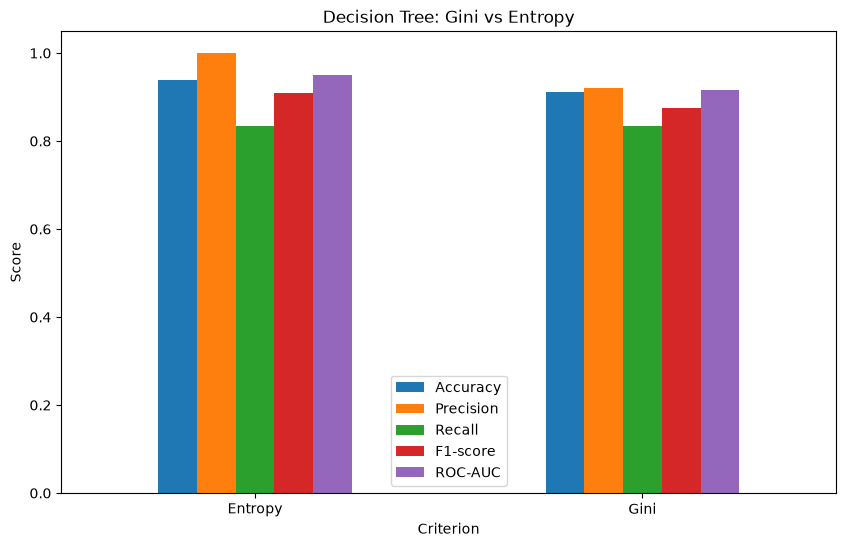

In [109]:
dt_plot = dt_comparison_df.set_index("Criterion")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
]

dt_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Decision Tree: Gini vs Entropy")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()

### Gini vs Entropy

Using the same optimum hyperparameters, Gini and Entropy are compared to determine whether the splitting criterion significantly affects classification performance.

In [110]:
depth_values = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]

depth_results = []

for depth in depth_values:

    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    train_accuracy = model.score(
        X_train_scaled,
        y_train
    )

    test_accuracy = model.score(
        X_test_scaled,
        y_test
    )

    depth_results.append({
        "Max Depth": depth if depth is not None else "None",
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

depth_results_df = pd.DataFrame(depth_results)

depth_results_df

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.927473,0.885965
1,2,0.927473,0.885965
2,3,0.956044,0.938596
3,4,0.978022,0.929825
4,5,0.991209,0.956140
5,6,0.995604,0.929825
6,8,1.000000,0.956140
7,10,1.000000,0.956140
8,15,1.000000,0.956140
9,20,1.000000,0.956140


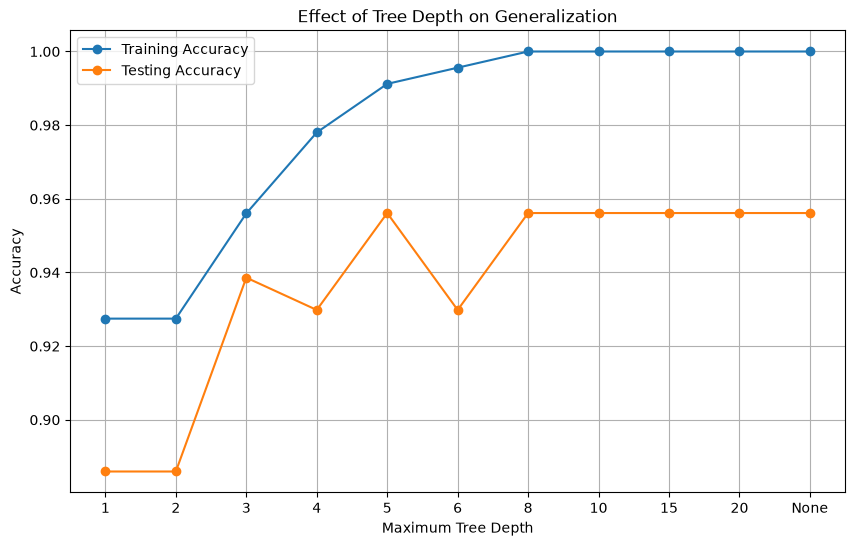

In [111]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(len(depth_values)),
    depth_results_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(len(depth_values)),
    depth_results_df["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xticks(
    range(len(depth_values)),
    [str(d) for d in depth_values]
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")

plt.title("Effect of Tree Depth on Generalization")

plt.legend()
plt.grid(True)

plt.show()

In [112]:
depth_results_df["Generalization Gap"] = (
    depth_results_df["Training Accuracy"]
    - depth_results_df["Testing Accuracy"]
)

depth_results_df

,Max Depth,Training Accuracy,Testing Accuracy,Generalization Gap
0,1,0.927473,0.885965,0.041508
1,2,0.927473,0.885965,0.041508
2,3,0.956044,0.938596,0.017447
3,4,0.978022,0.929825,0.048197
4,5,0.991209,0.956140,0.035068
5,6,0.995604,0.929825,0.065780
6,8,1.000000,0.956140,0.043860
7,10,1.000000,0.956140,0.043860
8,15,1.000000,0.956140,0.043860
9,20,1.000000,0.956140,0.043860


### Effect of Tree Depth

Increasing tree depth generally increases model complexity and training accuracy. The testing accuracy and generalization gap are examined to identify the point where deeper trees begin to overfit.

### Gini vs Entropy

Entropy outperformed Gini, achieving higher accuracy, F1-score, and ROC-AUC while producing zero false positives.

### Part E — Final Analysis

GridSearchCV identified Entropy with max_depth=6, min_samples_leaf=2, and min_samples_split=5 as the optimum configuration, achieving 94.95% cross-validation accuracy. Entropy performed better than Gini on the test set. Increasing tree depth improved training accuracy but excessive depth increased the generalization gap, indicating overfitting. The highest test accuracy in the depth experiment was 95.61%.

Part F: Random Forest Classifier

In [113]:
from sklearn.ensemble import RandomForestClassifier

### Part F: Random Forest Classifier

Random Forest combines multiple Decision Trees to improve classification performance and reduce the risk of overfitting.

In [114]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_baseline.fit(X_train_scaled, y_train)

y_pred_rf = rf_baseline.predict(X_test_scaled)
y_prob_rf = rf_baseline.predict_proba(X_test_scaled)[:, 1]

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [115]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

print("\nTN:", tn_rf)
print("FP:", fp_rf)
print("FN:", fn_rf)
print("TP:", tp_rf)

Accuracy : 0.9736842105263158
Precision: 1.0
Recall   : 0.9285714285714286
F1-score : 0.9629629629629629
ROC-AUC  : 0.9928902116402116

TN: 72
FP: 0
FN: 3
TP: 39


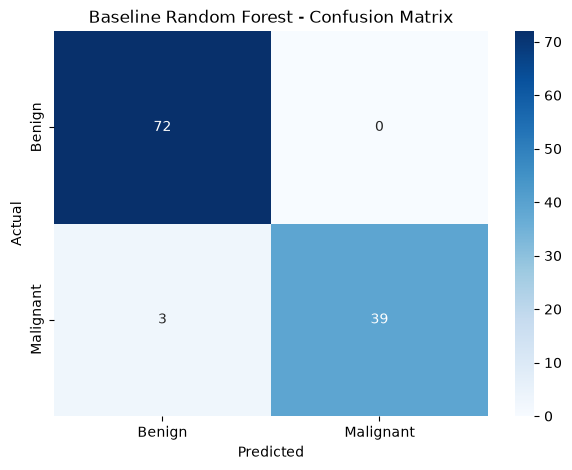

In [116]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Baseline Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Effect of Number of Trees

Increasing the number of trees beyond 50 did not improve test accuracy; 50 and 100 trees achieved 97.37%, while 200 trees decreased to 96.49%.

In [117]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Train Different Forest Sizes

In [118]:
n_estimators_values = [50, 100, 200]

rf_tree_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    rf_tree_results.append({
        "n_estimators": n,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

rf_tree_results_df = pd.DataFrame(rf_tree_results)

rf_tree_results_df

,n_estimators,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,50,0.973684,1.0,0.928571,0.962963,0.994048
1,100,0.973684,1.0,0.928571,0.962963,0.992890
2,200,0.964912,1.0,0.904762,0.950000,0.994213


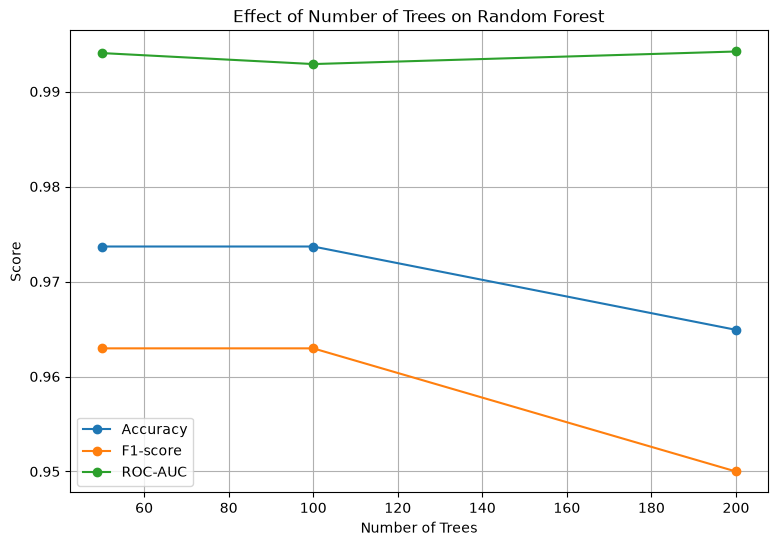

In [119]:
plt.figure(figsize=(9, 6))

plt.plot(
    rf_tree_results_df["n_estimators"],
    rf_tree_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    rf_tree_results_df["n_estimators"],
    rf_tree_results_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.plot(
    rf_tree_results_df["n_estimators"],
    rf_tree_results_df["ROC-AUC"],
    marker="o",
    label="ROC-AUC"
)

plt.xlabel("Number of Trees")
plt.ylabel("Score")
plt.title("Effect of Number of Trees on Random Forest")
plt.legend()
plt.grid(True)

plt.show()

### Effect of Number of Trees

Increasing the number of trees is evaluated to determine whether a larger Random Forest improves classification performance.

In [120]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

print("Random Forest hyperparameter grid created.")

Random Forest hyperparameter grid created.


In [121]:
rf_base = RandomForestClassifier(
    random_state=42
)

grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_rf.fit(
    X_train_scaled,
    y_train
)

print("Random Forest GridSearch completed.")

Random Forest GridSearch completed.


In [122]:
print("Best Random Forest Parameters:")
print(grid_search_rf.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search_rf.best_score_)

Best Random Forest Parameters:
{'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validation Accuracy:
0.9670329670329672


### Optimum Random Forest Hyperparameters

GridSearchCV selected Gini criterion, 50 trees, max_depth=10, sqrt max_features, and min_samples_split=2, achieving 96.70% cross-validation accuracy.

In [123]:
best_rf = grid_search_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test_scaled)
y_prob_best_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

best_rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

best_rf_precision = precision_score(
    y_test,
    y_pred_best_rf
)

best_rf_recall = recall_score(
    y_test,
    y_pred_best_rf
)

best_rf_f1 = f1_score(
    y_test,
    y_pred_best_rf
)

best_rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_best_rf
)

print("Accuracy :", best_rf_accuracy)
print("Precision:", best_rf_precision)
print("Recall   :", best_rf_recall)
print("F1-score :", best_rf_f1)
print("ROC-AUC  :", best_rf_roc_auc)

Accuracy : 0.9736842105263158
Precision: 1.0
Recall   : 0.9285714285714286
F1-score : 0.9629629629629629
ROC-AUC  : 0.9940476190476191


In [124]:
best_rf_params = grid_search_rf.best_params_.copy()

best_rf_params.pop("criterion")

rf_gini = RandomForestClassifier(
    **best_rf_params,
    criterion="gini",
    random_state=42
)

rf_entropy = RandomForestClassifier(
    **best_rf_params,
    criterion="entropy",
    random_state=42
)

rf_gini.fit(X_train_scaled, y_train)
rf_entropy.fit(X_train_scaled, y_train)

print("Gini and Entropy Random Forest models trained.")

Gini and Entropy Random Forest models trained.


In [125]:
rf_criterion_results = []

for name, model in [
    ("Gini", rf_gini),
    ("Entropy", rf_entropy)
]:

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    rf_criterion_results.append({
        "Criterion": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "FP": fp,
        "FN": fn
    })

rf_criterion_df = pd.DataFrame(
    rf_criterion_results
)

rf_criterion_df

,Criterion,Accuracy,Precision,Recall,F1-score,ROC-AUC,FP,FN
0,Gini,0.973684,1.0,0.928571,0.962963,0.994048,0,3
1,Entropy,0.973684,1.0,0.928571,0.962963,0.996032,0,3


### Gini vs Entropy

Gini and Entropy produced identical classification metrics, while Entropy achieved a slightly higher ROC-AUC (0.9960 vs 0.9940).

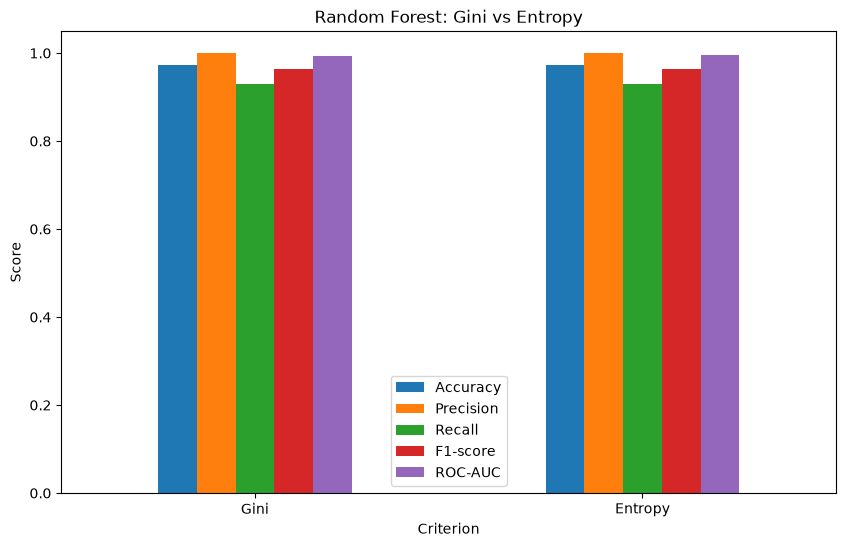

In [126]:
rf_criterion_plot = rf_criterion_df.set_index(
    "Criterion"
)[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
]

rf_criterion_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Random Forest: Gini vs Entropy")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()

### Gini vs Entropy

Gini and Entropy were compared using the tuned Random Forest hyperparameters to determine which splitting criterion provides better classification performance.

In [127]:
rf_depth_values = [2, 3, 4, 5, 6, 8, 10, 15, None]

rf_depth_results = []

for depth in rf_depth_values:

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    train_accuracy = model.score(
        X_train_scaled,
        y_train
    )

    test_accuracy = model.score(
        X_test_scaled,
        y_test
    )

    rf_depth_results.append({
        "Max Depth": depth if depth is not None else "None",
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

rf_depth_results_df = pd.DataFrame(
    rf_depth_results
)

rf_depth_results_df

,Max Depth,Training Accuracy,Testing Accuracy
0,2,0.956044,0.947368
1,3,0.978022,0.956140
2,4,0.989011,0.964912
3,5,0.993407,0.973684
4,6,0.995604,0.973684
5,8,1.000000,0.973684
6,10,1.000000,0.973684
7,15,1.000000,0.973684
8,None,1.000000,0.973684


In [128]:
rf_depth_results_df["Generalization Gap"] = (
    rf_depth_results_df["Training Accuracy"]
    - rf_depth_results_df["Testing Accuracy"]
)

rf_depth_results_df

,Max Depth,Training Accuracy,Testing Accuracy,Generalization Gap
0,2,0.956044,0.947368,0.008676
1,3,0.978022,0.956140,0.021882
2,4,0.989011,0.964912,0.024099
3,5,0.993407,0.973684,0.019722
4,6,0.995604,0.973684,0.021920
5,8,1.000000,0.973684,0.026316
6,10,1.000000,0.973684,0.026316
7,15,1.000000,0.973684,0.026316
8,None,1.000000,0.973684,0.026316


Does Increasing Depth Cause Overfitting?

Yes, mildly.

Your strongest evidence:

Depth 5
Training = 99.34%
Testing  = 97.37%


Depth 8+
Training = 100%
Testing  = 97.37%

The model is effectively memorizing the training data at greater depths, while test performance remains unchanged.

So increasing depth beyond approximately 5–6 does not improve generalization in this experiment.

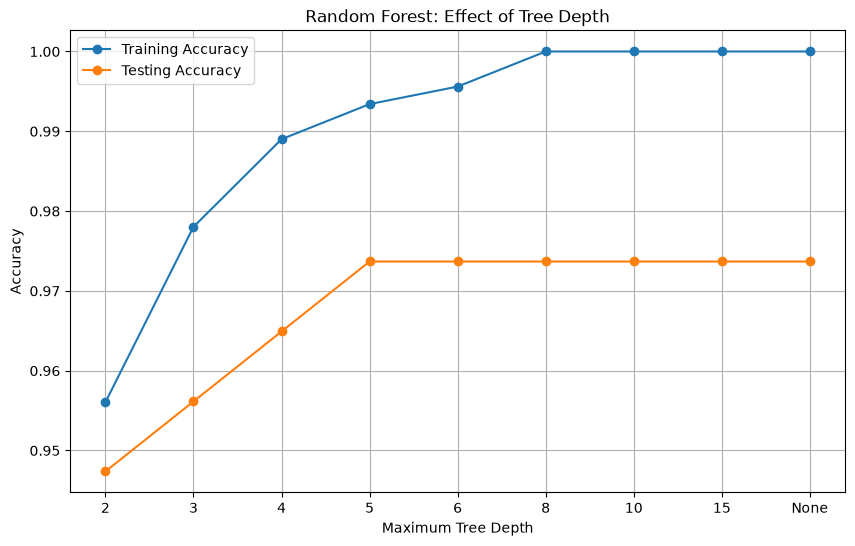

In [129]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(len(rf_depth_values)),
    rf_depth_results_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(len(rf_depth_values)),
    rf_depth_results_df["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xticks(
    range(len(rf_depth_values)),
    [str(d) for d in rf_depth_values]
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")

plt.title("Random Forest: Effect of Tree Depth")

plt.legend()
plt.grid(True)

plt.show()

### Part F — Final Analysis

The Random Forest achieved excellent performance, with 97.37% test accuracy and 99.40% ROC-AUC using 50 trees. GridSearchCV selected Gini, 50 trees, max_depth=10, sqrt max_features, and min_samples_split=2 as the optimum configuration. Gini and Entropy produced nearly identical results, with Entropy having a slightly higher ROC-AUC. Increasing tree depth beyond 5 did not improve test accuracy and increased the generalization gap, indicating mild overfitting.